# Predicting a TE's jump: who will beat his own track record next season?

Trey McBride rose from a baseline of about 8 PPR points per game to 15.2 in 2024 and 18.6 in 2025. Tucker Kraft jumped from a 7.8 baseline to 14.7 in 2025. Could those rises have been seen coming?

**Same method as the WR notebook** (`wr_jump_model.ipynb`), using the shared code in `jump_model.py`:
- **Baseline** = PPR points per game over this season and last, weighted by games played.
- **Change model** predicts next season's PPG minus that baseline (ridge regression).
- **Leap model** predicts the chance of a big leap: **+3 PPG over baseline and at least 11 PPG** (TEs score less than WRs, so the bar is lower; roughly TE1 territory).
- **Eligible:** 6+ games and 100+ routes.
- **Backtest:** each season from 2019 to 2024 is predicted using only earlier seasons. 2026 results are never used.

In [1]:
import sys
sys.path.append("..")                     # so we can import jump_model.py from the project folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import jump_model as jm

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

POS = "TE"
cfg = jm.POSITIONS[POS]
FEATURES = cfg["features"]

df = pd.read_parquet("../data/processed/player_seasons.parquet")
d = jm.prepare(df, POS)
pool = d[cfg["eligible"](d)].copy()

lab = pool[(pool["season"] <= 2024) & (pool["next_games"] >= 6)].copy()
lab["ppg_change"] = lab["next_ppr_per_game"] - lab["baseline_ppg"]
lab["leap"] = ((lab["ppg_change"] >= cfg["leap_gain"]) & (lab["next_ppr_per_game"] >= cfg["leap_floor"])).astype(int)
print(f"{len(lab)} {POS} seasons | average change {lab['ppg_change'].mean():+.2f} PPG | "
      f"big leaps: {lab['leap'].sum()} ({lab['leap'].mean():.1%})")

532 TE seasons | average change -0.31 PPG | big leaps: 26 (4.9%)


## Regression to the mean

Players with a high baseline usually fall back the next year; players with a low one tend to rise. The model has to account for this before anything else.

In [2]:
lab["baseline_bucket"] = pd.cut(lab["baseline_ppg"], [0, 5, 8, 11, 14, 18, 40])
lab.groupby("baseline_bucket", observed=True).agg(
    players=("ppg_change", "size"), avg_change=("ppg_change", "mean"), leap_rate=("leap", "mean")).round(2)

,players,avg_change,leap_rate
baseline_bucket,,,
"(0, 5]",230,0.39,0.01
"(5, 8]",145,-0.26,0.06
"(8, 11]",89,-1.27,0.08
"(11, 14]",47,-1.36,0.13
"(14, 18]",19,-2.13,0.11
"(18, 40]",2,-0.91,0.00


## The factors

| Group | Features |
|---|---|
| **Track record** | `baseline_ppg`, `ppr_per_game`, `second_half_trend` |
| **Efficiency** | targets per route run (`tprr`), yards per route run (`yprr`), `fp_over_expected_per_game` |
| **Current role** | `target_share`, `route_participation`, `xfp_per_game`, `rz_target_share` |
| **Career stage** | `age`, `years_exp`, `draft_pick_filled` |
| **Next season's opportunity** | `next_team_vacated_target_share`, `next_competition_target_share` (targets held by returning teammates), `next_preseason_depth_tier`, `depth_promotion`, `changed_team` |
| **Environment** | `qb_epa_per_dropback`, `team_pass_rate_over_exp`, `next_sos_pass_def_epa`, `games_missed` |
| **After the catch** | `yac_per_reception` |

Missing values are filled with the median, and the model is told they were missing.

## Backtest: each season predicted using only earlier seasons

In [3]:
results = []
for season in range(2019, 2025):
    train, test = lab[lab["season"] < season], lab[lab["season"] == season]
    out = test[["name", "season", "team", "next_preseason_team", "age", "baseline_ppg",
                "next_ppr_per_game", "ppg_change", "leap", "next_preseason_rank"]].copy()
    out["pred_change"] = jm.change_model().fit(train[FEATURES], train["ppg_change"]).predict(test[FEATURES])
    out["leap_prob"] = jm.leap_model().fit(train[FEATURES], train["leap"]).predict_proba(test[FEATURES])[:, 1]
    results.append(out)
bt = pd.concat(results)
bt["pct"] = bt.groupby("season")["pred_change"].rank(pct=True)   # 1.00 = model's top predicted riser that season

naive = bt["ppg_change"].abs().mean()
model = (bt["ppg_change"] - bt["pred_change"]).abs().mean()
print(f"Average miss on next-season PPG: naive {naive:.2f} vs model {model:.2f}")
print(f"Correlation of predicted vs actual change: {np.corrcoef(bt['pred_change'], bt['ppg_change'])[0, 1]:.2f}")
print(f"Leap model AUC: {roc_auc_score(bt['leap'], bt['leap_prob']):.2f}  (0.5 = coin flip, 1.0 = perfect)")

Average miss on next-season PPG: naive 2.14 vs model 1.98
Correlation of predicted vs actual change: 0.43
Leap model AUC: 0.82  (0.5 = coin flip, 1.0 = perfect)


In [4]:
bt["decile"] = bt.groupby("season")["pred_change"].transform(
    lambda s: pd.qcut(s.rank(method="first"), 10, labels=False) + 1)
deciles = bt.groupby("decile").agg(predicted=("pred_change", "mean"), actual=("ppg_change", "mean"),
                                   leap_rate=("leap", "mean"), players=("leap", "size"))
deciles.round(2)

,predicted,actual,leap_rate,players
decile,,,,
1,-3.29,-2.87,0.00,40
2,-1.89,-1.32,0.08,37
3,-1.23,-1.05,0.00,38
4,-0.77,-0.47,0.03,35
5,-0.31,-0.61,0.03,38
6,0.06,0.19,0.06,36
7,0.44,0.93,0.09,35
8,0.83,-0.37,0.03,38
9,1.32,0.88,0.05,37


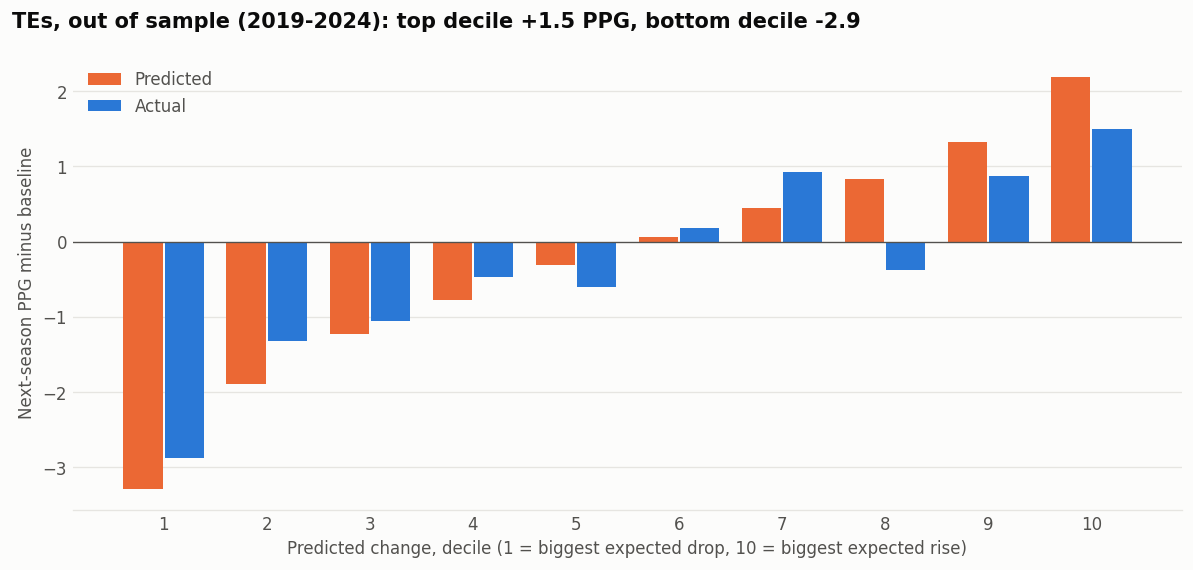

In [5]:
SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"

def style(ax, fig):
    fig.patch.set_facecolor(SURF); ax.set_facecolor(SURF)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID); ax.tick_params(colors=INK2, length=0); ax.set_axisbelow(True)

top, bottom = deciles["actual"].iloc[-1], deciles["actual"].iloc[0]
fig, ax = plt.subplots(figsize=(10, 4.8), dpi=120); style(ax, fig)
x = np.arange(1, 11); w = 0.38
ax.bar(x - w/2 - 0.01, deciles["predicted"], w, color=ORANGE, label="Predicted")
ax.bar(x + w/2 + 0.01, deciles["actual"], w, color=BLUE, label="Actual")
ax.axhline(0, color=INK2, lw=0.8)
ax.set_xticks(x)
ax.set_xlabel("Predicted change, decile (1 = biggest expected drop, 10 = biggest expected rise)", color=INK2)
ax.set_ylabel("Next-season PPG minus baseline", color=INK2)
fig.suptitle(f"TEs, out of sample (2019-2024): top decile {top:+.1f} PPG, bottom decile {bottom:+.1f}",
             x=0.01, ha="left", color=INK, fontsize=12.5, fontweight="bold")
ax.legend(frameon=False, loc="upper left", labelcolor=INK2); ax.grid(axis="y", color=GRID)
plt.tight_layout(); plt.show()

## What drives a jump?

Weights from the change model trained on all 2016-2024 seasons. Features are standardized, so bars are comparable: each is the PPG change for a one-standard-deviation increase **with the other features held constant**. Features that move together (age and years of experience, for example) split credit between them, so read related bars as a group.

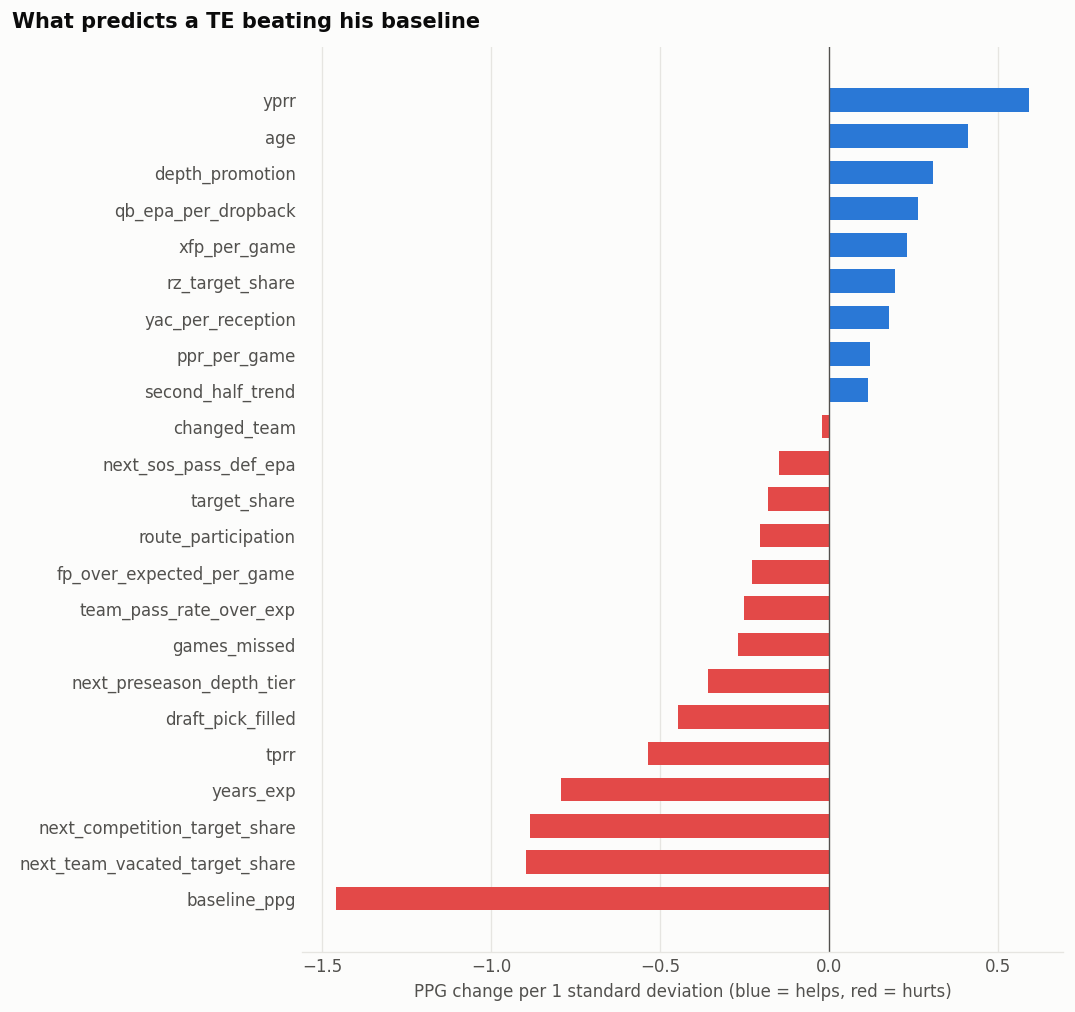

In [6]:
final_change = jm.change_model().fit(lab[FEATURES], lab["ppg_change"])
weights = pd.Series(final_change[-1].coef_[:len(FEATURES)], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 0.32 * len(weights) + 1.2), dpi=120); style(ax, fig)
ax.barh(weights.index, weights.values, color=[BLUE if v > 0 else RED for v in weights.values], height=0.65)
ax.axvline(0, color=INK2, lw=0.8)
ax.set_xlabel("PPG change per 1 standard deviation (blue = helps, red = hurts)", color=INK2)
fig.suptitle("What predicts a TE beating his baseline", x=0.01, ha="left", color=INK, fontsize=12.5, fontweight="bold")
ax.grid(axis="x", color=GRID)
plt.tight_layout(); plt.show()

## The biggest jumps of 2019-2024: did the model see them coming?

`pct` = where the model ranked the player's predicted change among all eligible players that season (1.00 = top). Not cherry-picked: these are simply the largest actual gains.

In [7]:
cols = ["name", "season", "next_preseason_team", "age", "baseline_ppg", "next_ppr_per_game",
        "ppg_change", "pred_change", "pct", "leap_prob"]
bt.sort_values("ppg_change", ascending=False)[cols].head(12).round(2)

,name,season,next_preseason_team,age,baseline_ppg,next_ppr_per_game,ppg_change,pred_change,pct,leap_prob
427,Logan Thomas,2019,WAS,28.2,2.48,11.04,8.56,2.23,0.89,0.01
906,Jonnu Smith,2023,MIA,28.0,6.08,13.08,7.00,-1.34,0.14,0.12
896,Trey McBride,2023,ARI,23.8,8.38,15.24,6.86,2.12,0.94,0.22
1022,Tucker Kraft,2024,GB,23.8,7.80,14.65,6.85,1.89,1.00,0.66
809,Jake Ferguson,2022,DAL,23.6,4.40,10.42,6.02,2.66,0.98,0.04
1014,Trey McBride,2024,ARI,24.8,12.89,18.58,5.69,0.19,0.69,0.27
378,Darren Waller,2019,LV,27.0,11.83,17.41,5.58,-0.83,0.43,0.49
801,Trey McBride,2022,ARI,22.8,5.12,10.68,5.55,1.40,0.87,0.01
512,Dalton Schultz,2020,DAL,24.1,6.73,12.28,5.55,-0.04,0.60,0.03
396,Taysom Hill,2019,NaN,29.0,4.38,9.79,5.41,1.51,0.82,0.05


## Case studies

In [8]:
bt[bt["name"].isin(['Trey McBride', 'Tucker Kraft', 'Jonnu Smith', 'Jake Ferguson'])][cols].sort_values(["name", "season"]).round(2)

,name,season,next_preseason_team,age,baseline_ppg,next_ppr_per_game,ppg_change,pred_change,pct,leap_prob
809,Jake Ferguson,2022,DAL,23.6,4.40,10.42,6.02,2.66,0.98,0.04
898,Jake Ferguson,2023,DAL,24.6,8.05,7.46,-0.60,1.30,0.74,0.27
1037,Jake Ferguson,2024,DAL,25.6,9.08,11.06,1.98,-1.32,0.25,0.02
395,Jonnu Smith,2019,TEN,24.0,6.24,10.01,3.77,3.02,0.98,0.36
517,Jonnu Smith,2020,NE,25.0,8.44,4.21,-4.23,-1.45,0.31,0.06
666,Jonnu Smith,2021,NE,26.0,6.92,4.33,-2.59,0.44,0.66,0.05
808,Jonnu Smith,2022,ATL,27.0,4.26,7.31,3.04,0.64,0.68,0.02
906,Jonnu Smith,2023,MIA,28.0,6.08,13.08,7.00,-1.34,0.14,0.12
1016,Jonnu Smith,2024,PIT,29.0,10.19,5.01,-5.18,-1.07,0.32,0.09
801,Trey McBride,2022,ARI,22.8,5.12,10.68,5.55,1.40,0.87,0.01


## 2026 predictions

Both models retrained on every labeled season (2016-2024), then applied to 2025 seasons. `next_preseason_rank` is the FantasyPros consensus positional rank before the 2026 season.

In [9]:
final_leap = jm.leap_model().fit(lab[FEATURES], lab["leap"])
now = pool[pool["season"] == 2025].copy()
now["pred_change_2026"] = final_change.predict(now[FEATURES])
now["pred_ppg_2026"] = now["baseline_ppg"] + now["pred_change_2026"]
now["leap_prob_2026"] = final_leap.predict_proba(now[FEATURES])[:, 1]
show = ["name", "next_preseason_team", "age", "baseline_ppg", "pred_ppg_2026", "pred_change_2026",
        "leap_prob_2026", "next_preseason_rank"]

# Most likely to make a big leap
now.sort_values("leap_prob_2026", ascending=False)[show].head(12).round(2)

,name,next_preseason_team,age,baseline_ppg,pred_ppg_2026,pred_change_2026,leap_prob_2026,next_preseason_rank
1143,Tyler Warren,IND,23.3,11.09,12.16,1.08,0.42,4.0
1153,AJ Barner,SEA,23.3,7.06,7.95,0.89,0.26,23.0
1159,Dalton Kincaid,BUF,25.9,9.08,10.05,0.97,0.26,11.0
1151,Colston Loveland,CHI,21.4,10.32,11.19,0.87,0.25,3.0
1141,Kyle Pitts,ATL,24.9,10.06,10.03,-0.03,0.18,7.0
1148,Hunter Henry,NE,30.7,9.82,9.94,0.11,0.17,20.0
1144,Jake Ferguson,DAL,26.6,9.44,9.27,-0.17,0.16,14.0
1140,Trey McBride,ARI,25.8,16.96,14.75,-2.21,0.14,1.0
1182,Greg Dulcich,MIA,25.4,5.43,6.57,1.14,0.10,24.0
1155,Mark Andrews,BAL,30.0,9.41,8.86,-0.55,0.10,16.0


In [10]:
# Biggest predicted risers among players who already have a real role (baseline 6+ PPG)
now[now["baseline_ppg"] >= 6].sort_values("pred_change_2026", ascending=False)[show].head(10).round(2)

,name,next_preseason_team,age,baseline_ppg,pred_ppg_2026,pred_change_2026,leap_prob_2026,next_preseason_rank
1156,Colby Parkinson,LA,26.7,6.51,7.96,1.46,0.05,32.0
1143,Tyler Warren,IND,23.3,11.09,12.16,1.08,0.42,4.0
1159,Dalton Kincaid,BUF,25.9,9.08,10.05,0.97,0.26,11.0
1153,AJ Barner,SEA,23.3,7.06,7.95,0.89,0.26,23.0
1151,Colston Loveland,CHI,21.4,10.32,11.19,0.87,0.25,3.0
1171,Mason Taylor,NYJ,21.3,6.84,7.27,0.43,0.03,34.0
1175,Cole Kmet,CHI,26.5,6.22,6.39,0.17,0.03,46.0
1148,Hunter Henry,NE,30.7,9.82,9.94,0.11,0.17,20.0
1162,Brenton Strange,JAX,24.7,8.04,8.13,0.08,0.02,18.0
1141,Kyle Pitts,ATL,24.9,10.06,10.03,-0.03,0.18,7.0


In [11]:
# Potential bargains: ranked outside the top 12 TEs, sorted by predicted 2026 PPG
now[now["next_preseason_rank"] > 12].sort_values("pred_ppg_2026", ascending=False)[show].head(10).round(2)

,name,next_preseason_team,age,baseline_ppg,pred_ppg_2026,pred_change_2026,leap_prob_2026,next_preseason_rank
1148,Hunter Henry,NE,30.7,9.82,9.94,0.11,0.17,20.0
1146,Dallas Goedert,PHI,30.7,11.55,9.50,-2.04,0.02,13.0
1144,Jake Ferguson,DAL,26.6,9.44,9.27,-0.17,0.16,14.0
1155,Mark Andrews,BAL,30.0,9.41,8.86,-0.55,0.10,16.0
1161,Cade Otton,TB,26.4,9.06,8.59,-0.47,0.04,29.0
1164,Pat Freiermuth,PIT,26.9,8.87,8.47,-0.41,0.04,28.0
1147,Juwan Johnson,NO,29.0,9.46,8.37,-1.09,0.05,15.0
1162,Brenton Strange,JAX,24.7,8.04,8.13,0.08,0.02,18.0
1149,Dalton Schultz,HOU,29.1,8.70,8.04,-0.66,0.06,17.0
1156,Colby Parkinson,LA,26.7,6.51,7.96,1.46,0.05,32.0


### Early 2026 check

If `grade_2026.py` has been run, this compares the predictions with 2026 results so far. A few games is mostly noise, so treat this as a progress report, not a verdict.

In [12]:
from pathlib import Path
grades_path = Path("../predictions/2026_grades.csv")
if grades_path.exists():
    g = pd.read_csv(grades_path)
    g = g[(g["position"] == POS) & (g["games_2026"] >= 2)]
    print(f"Through week {int(g['through_week'].max())}: {len(g)} TEs with 2+ games")
    display(g.sort_values("leap_prob_2026", ascending=False)[
        ["name", "baseline_ppg", "pred_ppg_2026", "leap_prob_2026", "games_2026", "ppg_2026"]].head(12).round(2))
else:
    print("Run grade_2026.py first to see 2026 results.")

Through week 4: 67 TEs with 2+ games


,name,baseline_ppg,pred_ppg_2026,leap_prob_2026,games_2026,ppg_2026
52,Tyler Warren,11.09,11.76,0.32,4.0,12.12
78,Dalton Kincaid,9.08,10.28,0.30,4.0,11.50
60,Colston Loveland,10.32,11.24,0.29,4.0,5.03
117,AJ Barner,7.06,7.98,0.27,4.0,6.32
83,Kyle Pitts,10.06,9.80,0.22,4.0,2.92
98,Jake Ferguson,9.44,9.20,0.16,4.0,9.07
84,Hunter Henry,9.82,9.77,0.15,4.0,6.32
18,Trey McBride,16.96,14.44,0.14,4.0,17.30
100,Mark Andrews,9.41,8.92,0.14,4.0,9.72
41,Brock Bowers,15.13,12.54,0.09,2.0,24.10


## Takeaways

1. **Yards per route run is the strongest positive signal.** TEs who already produce efficiently on the routes they run tend to earn more of them.
2. **TEs develop late.** Holding experience constant, older TEs actually rise more, while more years in the league points the other way. These two move together (multicollinearity), so read them as a pair: *late-blooming TEs in their first few seasons* is the profile. Don't read either weight alone.
3. **Promotion matters.** Moving up the depth chart and a good QB both help; changing teams and missing games hurt.
4. **Leaps are rare (about 5%), but the leap model separates them well** (AUC around 0.8, the best of the three positions). Tucker Kraft's 2025 jump got the model's highest predicted rise that season, and Trey McBride's 2024 breakout was in its top 6%.
5. **What the model missed:** Jonnu Smith's 2024 leap came after a trade to Miami, a situation the data couldn't capture.

**Caveats:** small samples (a few dozen leaps per position), linear models that can't capture every interaction, and no coaching data yet.